# 02_eda — 타깃(발전량) 탐색적 데이터 분석

**목적(Why)**: 이 프로젝트는 모델을 만들기 전에 데이터를 이해하는 것을 최우선으로 합니다 (CLAUDE.md 2장). 이 노트북에서는 가장 먼저 예측 대상인 `kpx_group_1/2/3` 발전량 자체를 들여다봅니다.

**입력**: `data/train/train_labels.csv` (1절), `data/processed/*.parquet` (2절부터 — `01_preprocessing.ipynb`가 만든 캐시)
**출력**: 이 노트북의 그림·표 → 이후 `reports/02_eda.md`로 정리

체크리스트 진행 상황: 1절(타깃) 완료, 2절(기상 예보) 이번 배치, 3~5절(타깃×기상 관계, SCADA, 시간 무결성)은 다음 배치.

## 0. 환경 설정

이 셀은 라이브러리를 불러오고 경로·상수를 정하는 준비 셀입니다. 계산은 하지 않습니다.

In [1]:
import sys
print(sys.executable)  # venv 안의 파이썬을 쓰고 있는지 확인

c:\Users\cho03\Desktop\wind_forecast_new\venv\Scripts\python.exe


**확인할 것**: 경로에 `wind_forecast\venv`가 포함되어 있어야 합니다 (가상환경 커널을 쓰고 있다는 뜻).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["font.family"] = "Malgun Gothic"  # 한글 깨짐 방지 (Windows 기본 한글 폰트)
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 50)

SEED = 42
np.random.seed(SEED)

TRAIN_LABELS_PATH = "../data/train/train_labels.csv"
PROCESSED_DIR = "../data/processed"

CAPACITY_KWH = {
    "kpx_group_1": 21600,
    "kpx_group_2": 21600,
    "kpx_group_3": 21000,
}
GROUP_COLS = list(CAPACITY_KWH.keys())

## 1. 타깃(train_labels.csv) 탐색

### 1-1. 데이터 로드

원본 CSV를 그대로 불러와서 shape·컬럼·자료형을 확인합니다. `kst_dtm`을 시간 타입으로 바꿔서 이후 시계열 연산(월별 집계, 시간대별 평균 등)이 되도록 준비합니다.

In [3]:
labels = pd.read_csv(TRAIN_LABELS_PATH, encoding="utf-8-sig")
labels["kst_dtm"] = pd.to_datetime(labels["kst_dtm"])

print(labels.shape)
print(labels.dtypes)
labels.head(3)

(26304, 4)
kst_dtm        datetime64[us]
kpx_group_1           float64
kpx_group_2           float64
kpx_group_3           float64
dtype: object


,kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3
0,2022-01-01 01:00:00,12004.421,9719.242,NaN
1,2022-01-01 02:00:00,12901.137,10297.768,NaN
2,2022-01-01 03:00:00,12091.200,10731.663,NaN


**확인할 것**
- shape이 `(26304, 4)`여야 합니다 (data_description.md 기준)
- `kst_dtm`이 `datetime64` 타입으로 바뀌었는지
- `kpx_group_3` 초반 값이 NaN(빈칸)인지 — 2022년엔 group_3 라벨이 없다고 문서에 적혀 있으므로

### 1-2. 그룹별 라벨 제공 기간 확인

data_description.md에는 group_1/2는 2022~2024년, group_3은 2023~2024년만 값이 있다고 적혀 있습니다. 문서와 실제 데이터가 다를 수도 있으니 항상 실데이터로 직접 확인합니다.

In [4]:
for col in GROUP_COLS:
    valid = labels.dropna(subset=[col])
    print(col, "->", valid["kst_dtm"].min(), "~", valid["kst_dtm"].max(), "| 유효 행 수:", len(valid))

kpx_group_1 -> 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 26200
kpx_group_2 -> 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 26201
kpx_group_3 -> 2023-01-01 01:00:00 ~ 2025-01-01 00:00:00 | 유효 행 수: 17538


**확인할 것**
- group_1, group_2는 2022-01-01부터 시작하는지
- group_3은 2023년 몇 월부터 시작하는지 (정확한 시작일)
- 유효 행 수 차이 — 이후 검증 B안(확장 윈도우 fold1)에서 group_3 학습 데이터가 얼마나 얕은지 가늠하는 근거가 됩니다

### 1-3. 발전량 분포 확인

무풍 시간대(0 근처)와 정격 근처(설비용량 부근) 두 군데에 값이 몰리는 '쌍봉 분포'를 예상합니다 — 파워커브(풍속-발전량 관계) 특성상 풍속이 컷인(cut-in, 터빈이 돌기 시작하는 최소 풍속) 이하면 0에 가깝고, 정격풍속 이상이면 설비용량 근처에서 평평해지기 때문입니다.

설비용량을 넘는 값이 있는지도 함께 봅니다 — 있다고 해서 무조건 삭제하지 않습니다. 실제 운영 데이터의 계측 여유율일 수 있어서, 먼저 얼마나·왜 넘는지부터 기록합니다(CLAUDE.md 2.4절, 출력제한/이상치는 지우지 않고 이해한다).

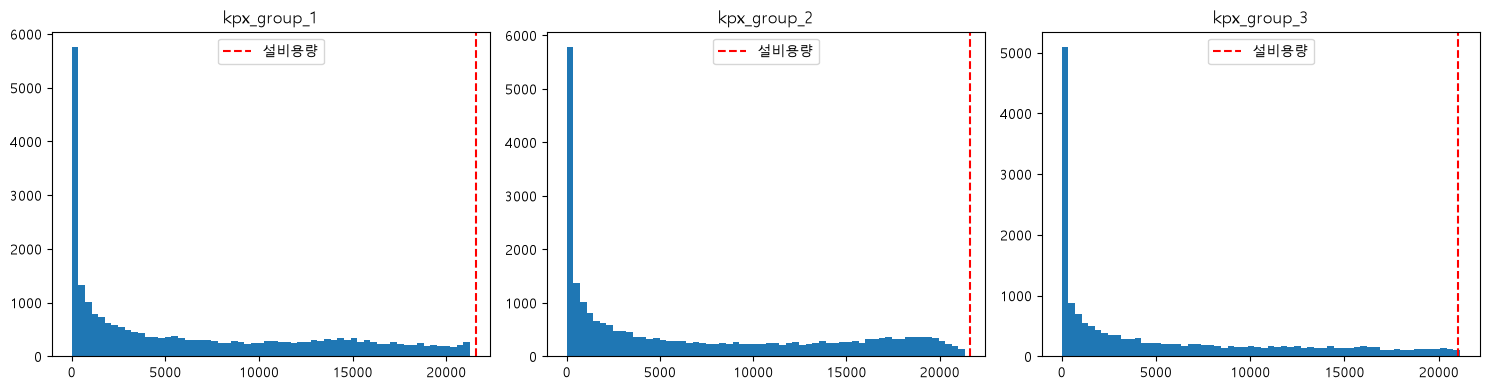

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, GROUP_COLS):
    data = labels[col].dropna()
    ax.hist(data, bins=60)
    ax.axvline(CAPACITY_KWH[col], color="red", linestyle="--", label="설비용량")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

In [6]:
for col in GROUP_COLS:
    data = labels[col].dropna()
    over = (data > CAPACITY_KWH[col]).sum()
    print(col, "설비용량 초과 건수:", over, f"({over/len(data)*100:.2f}%)")
    print(data.describe())
    print()

kpx_group_1 설비용량 초과 건수: 0 (0.00%)
count    26200.000000
mean      6621.981125
std       6582.443128
min          0.000000
25%        549.600000
50%       4252.168000
75%      12206.905000
max      21275.305000
Name: kpx_group_1, dtype: float64

kpx_group_2 설비용량 초과 건수: 0 (0.00%)
count    26201.000000
mean      7076.842859
std       7001.146068
min          0.000000
25%        549.600000
50%       4382.337000
75%      13508.589000
max      21362.084000
Name: kpx_group_2, dtype: float64

kpx_group_3 설비용량 초과 건수: 38 (0.22%)
count    17538.000000
mean      5563.819649
std       6294.582901
min          0.000000
25%        159.095000
50%       2719.074000
75%       9979.579000
max      21130.674000
Name: kpx_group_3, dtype: float64



**확인할 것**
- 히스토그램이 0 근처와 설비용량 근처 두 군데에 많이 몰려있는 쌍봉 모양인지
- 설비용량 초과 건수가 있다면 전체의 몇 %인지, 얼마나 초과하는지 (예: 1~2% 정도의 소폭 초과면 계측 여유율로 볼 수 있음)

### 1-4. 평가 대상 시간대 비율 (10% 룰)

`src/metric.py`는 **실제 발전량이 설비용량의 10% 이상인 시간대만** 채점합니다. 저발전 시간(무풍 등)은 아무리 예측이 틀려도 점수에 영향이 없다는 뜻이라, 모델이 어디에 집중해야 하는지 결정하는 핵심 숫자입니다.

In [7]:
for col in GROUP_COLS:
    data = labels[col].dropna()
    valid_mask = data >= CAPACITY_KWH[col] * 0.10
    print(col, f"평가 대상 비율: {valid_mask.mean()*100:.1f}%  (전체 {len(data)}건 중 {valid_mask.sum()}건)")

kpx_group_1 평가 대상 비율: 60.7%  (전체 26200건 중 15915건)
kpx_group_2 평가 대상 비율: 60.7%  (전체 26201건 중 15891건)
kpx_group_3 평가 대상 비율: 53.7%  (전체 17538건 중 9414건)


**확인할 것**
- 그룹별로 평가 대상 비율이 얼마나 차이나는지 (풍황 차이를 시사할 수 있음)
- 이 비율이 낮을수록(예: 60%대) 저발전 구간이 자주 등장한다는 뜻 — 나중에 손실함수·샘플가중치 설계에 참고할 숫자입니다

### 1-5. 월별 시계열과 이상 구간 확인

월별 평균 발전량을 그려서 계절 패턴(겨울에 바람이 강해지는 산악 지형 특성)을 확인하고, 오랫동안 0이 이어지는 구간(터빈 정지·점검 의심)이 있는지 찾습니다.

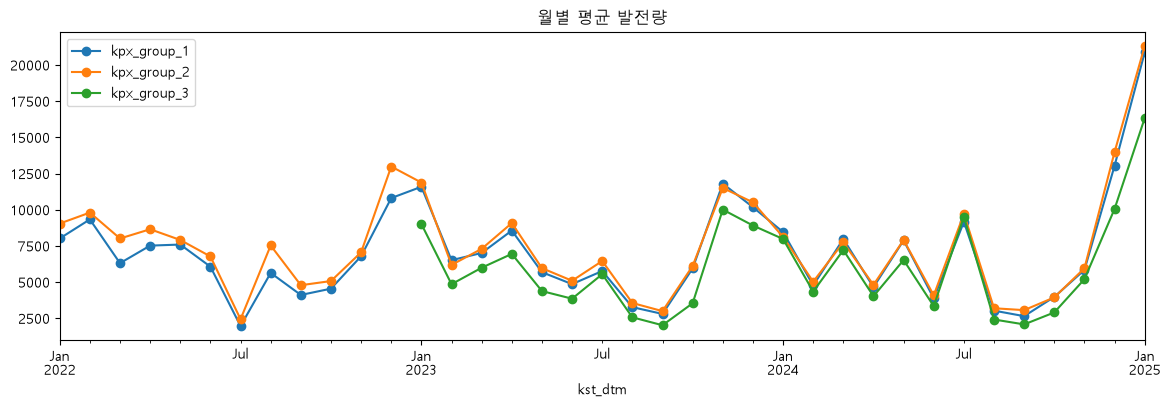

In [8]:
monthly = labels.set_index("kst_dtm")[GROUP_COLS].resample("MS").mean()

fig, ax = plt.subplots(figsize=(14, 4))
monthly.plot(ax=ax, marker="o")
ax.set_title("월별 평균 발전량")
plt.show()

In [9]:
# 24시간 이상 연속으로 0이 찍힌 구간이 몇 번 있는지 확인 (터빈 정지/결측 의심 구간 후보)
for col in GROUP_COLS:
    s = labels.set_index("kst_dtm")[col].dropna()
    is_zero = s == 0
    zero_run_id = (~is_zero).cumsum()
    run_lengths = is_zero.groupby(zero_run_id).sum()
    long_runs = run_lengths[run_lengths >= 24]
    print(col, "24시간 이상 연속 0 구간 개수:", len(long_runs))

kpx_group_1 24시간 이상 연속 0 구간 개수: 7
kpx_group_2 24시간 이상 연속 0 구간 개수: 6
kpx_group_3 24시간 이상 연속 0 구간 개수: 6


**확인할 것**
- 겨울(12~2월)이 여름보다 평균 발전량이 뚜렷이 높은지 (태백 산악풍 특성상 예상되는 패턴)
- 24시간 이상 연속 0 구간이 몇 번 있는지 — 있다면 다음 단계에서 그 날짜를 콕 집어 원인(정비/결측/실제 무풍)을 확인해야 합니다

### 1-6. 그룹 간 상관관계

세 그룹 모두 같은 가덕산 단지 안에 있으므로 날씨가 비슷해 상관이 높을 것으로 예상합니다. 상관이 실제로 얼마나 높은지 확인하면, 그룹을 따로 모델링할지 정보를 공유할지 판단하는 근거가 됩니다.

In [10]:
corr = labels[GROUP_COLS].corr()
corr

,kpx_group_1,kpx_group_2,kpx_group_3
kpx_group_1,1.000000,0.955350,0.903694
kpx_group_2,0.955350,1.000000,0.928294
kpx_group_3,0.903694,0.928294,1.000000


**확인할 것**
- 상관계수가 대부분 0.8 이상으로 높게 나오는지 (같은 단지이므로 예상되는 수준)
- 유독 상관이 낮은 쌍이 있다면 터빈 제작사(VESTAS vs UNISON) 차이나 위치 차이를 의심해볼 대상입니다

### 1-7. 시간대별(일주기) 평균 발전량

산악 지형은 낮과 밤의 기온차로 생기는 국지풍(산곡풍) 때문에 시간대별로 바람 패턴이 달라질 수 있습니다. 시간대별 평균을 보면 이 패턴이 실제로 존재하는지 확인할 수 있습니다.

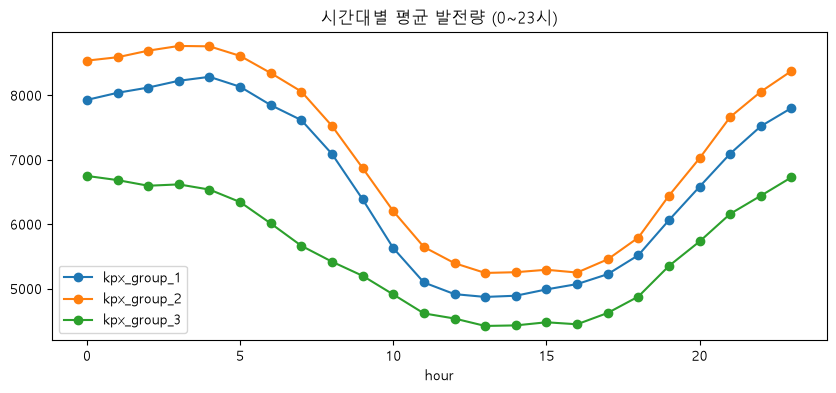

In [11]:
labels["hour"] = labels["kst_dtm"].dt.hour
hourly_profile = labels.groupby("hour")[GROUP_COLS].mean()

fig, ax = plt.subplots(figsize=(10, 4))
hourly_profile.plot(ax=ax, marker="o")
ax.set_title("시간대별 평균 발전량 (0~23시)")
plt.show()

**확인할 것**
- 특정 시간대(예: 새벽 vs 낮)에 뚜렷한 차이가 있는지
- 있다면 '시간(hour)'을 피처로 넣을 근거가 됩니다

### 1-8. 연도별 분포 변화 (Drift 확인)

CLAUDE.md 2.3절: 연도마다 기상 조건이 달라질 수 있어, 2022년 데이터를 많이 쓰는 것이 오히려 성능을 해칠 수도 있습니다. 연도별 분포를 비교해 이 위험이 실제로 있는지 확인합니다. 이 결과는 앞서 정한 A안+B안 병행 검증 전략의 근거를 강화하거나 재검토하는 데 씁니다.

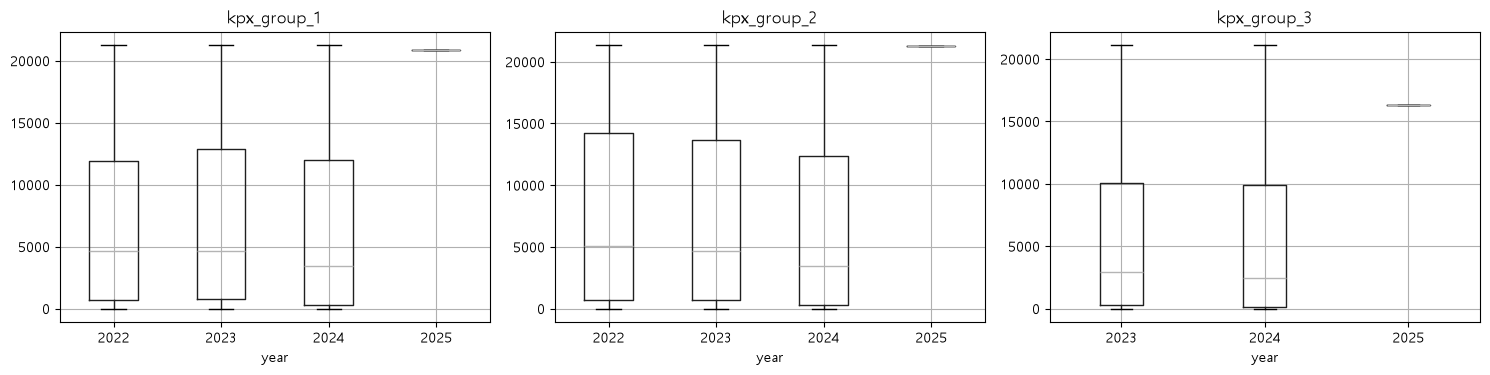

,kpx_group_1,kpx_group_2,kpx_group_3
year,,,
2022,6561.329096,7520.534942,NaN
2023,7000.421112,7226.109431,5638.874657
2024,6302.687647,6488.365732,5487.700727
2025,20870.337000,21304.232000,16328.905000


In [12]:
labels["year"] = labels["kst_dtm"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, GROUP_COLS):
    data = labels[["year", col]].dropna()
    data.boxplot(column=col, by="year", ax=ax)
    ax.set_title(col)
plt.suptitle("")
plt.tight_layout()
plt.show()

labels.groupby("year")[GROUP_COLS].mean()

**확인할 것**
- 연도별 평균/분포가 눈에 띄게 다른 해가 있는지
- 있다면 검증 전략(A안: 2024를 검증으로 씀)에서 2024년이 대표성 있는 해인지 다시 짚어봐야 합니다

## 2. 기상 예보(GFS/LDAPS) 탐색

이제부터는 `01_preprocessing.ipynb`가 만든 parquet 캐시를 불러와서 봅니다. 이미 격자별로 넓게 펼쳐진 형태라, 매번 원본 CSV를 pivot할 필요가 없습니다.

In [13]:
train_base = pd.read_parquet(f"{PROCESSED_DIR}/train_base.parquet")
test_base = pd.read_parquet(f"{PROCESSED_DIR}/test_base.parquet")
gfs_grid_meta = pd.read_parquet(f"{PROCESSED_DIR}/gfs_grid_meta.parquet")
ldaps_grid_meta = pd.read_parquet(f"{PROCESSED_DIR}/ldaps_grid_meta.parquet")

print("train_base:", train_base.shape, "| test_base:", test_base.shape)
print("gfs_grid_meta:", gfs_grid_meta.shape, "| ldaps_grid_meta:", ldaps_grid_meta.shape)

train_base: (26304, 804) | test_base: (8760, 798)
gfs_grid_meta: (9, 3) | ldaps_grid_meta: (16, 3)


**확인할 것**: `train_base`가 `(26304, 804)`, `test_base`가 `(8760, 798)` — 01_preprocessing에서 확인한 값과 같아야 합니다.

### 2-1. 격자 위치 지도 — 터빈과 얼마나 가까운가

GFS는 9개, LDAPS는 16개 격자가 있습니다. 어느 격자가 실제 터빈(태백 가덕산)에 가장 가까운지 확인해야, 나중에(`03_features.ipynb`) '최근접 격자' 피처를 근거 있게 고를 수 있습니다.

`info.xlsx`의 '좌표(Google)'는 도-분-초(DMS, 예: `37°16'55.61"N`) 형식이라 십진수 좌표로 바꿔서 격자 위경도와 같은 그래프에 겹쳐 그립니다.

In [14]:
info = pd.read_excel("../data/info.xlsx", sheet_name="info", header=3)
info = info.dropna(subset=["호기"]).reset_index(drop=True)
info["KPX그룹"] = info["KPX그룹"].ffill()
info.head(3)

,Unnamed: 0,단계,명칭,제작사,모델명,호기,좌표(Google),KPX그룹,Hub Height(m),Rotor Diameter(m),설비용량(MW),그룹설비용량(MW)
0,NaN,1,태백가덕산,VESTAS,V126,1,"37°16'55.61""N 128°57'02.10""E",1.0,117,126,3.6,21.6
1,NaN,1,태백가덕산,VESTAS,V126,2,"37°17'04.05""N 128°56'58.35""E",1.0,117,126,3.6,NaN
2,NaN,1,태백가덕산,VESTAS,V126,3,"37°17'11.49""N 128°56'58.99""E",1.0,117,126,3.6,NaN


In [15]:
import re


def dms_to_decimal(dms_str: str) -> tuple[float, float]:
    """'37°16'55.61"N 128°57'02.10"E' 형태의 문자열을 (위도, 경도) 십진수로 변환."""
    pattern = r"(\d+)\D+(\d+)\D+([\d.]+)\D*([NS])\s+(\d+)\D+(\d+)\D+([\d.]+)\D*([EW])"
    lat_d, lat_m, lat_s, lat_dir, lon_d, lon_m, lon_s, lon_dir = re.match(pattern, dms_str.strip()).groups()
    lat = float(lat_d) + float(lat_m) / 60 + float(lat_s) / 3600
    lon = float(lon_d) + float(lon_m) / 60 + float(lon_s) / 3600
    lat = -lat if lat_dir == "S" else lat
    lon = -lon if lon_dir == "W" else lon
    return lat, lon


turbine_coords = info[["제작사", "호기", "KPX그룹", "좌표(Google)"]].copy()
turbine_coords[["lat", "lon"]] = turbine_coords["좌표(Google)"].apply(lambda s: pd.Series(dms_to_decimal(s)))
turbine_coords.head(3)

,제작사,호기,KPX그룹,좌표(Google),lat,lon
0,VESTAS,1,1.0,"37°16'55.61""N 128°57'02.10""E",37.282114,128.950583
1,VESTAS,2,1.0,"37°17'04.05""N 128°56'58.35""E",37.284458,128.949542
2,VESTAS,3,1.0,"37°17'11.49""N 128°56'58.99""E",37.286525,128.949719


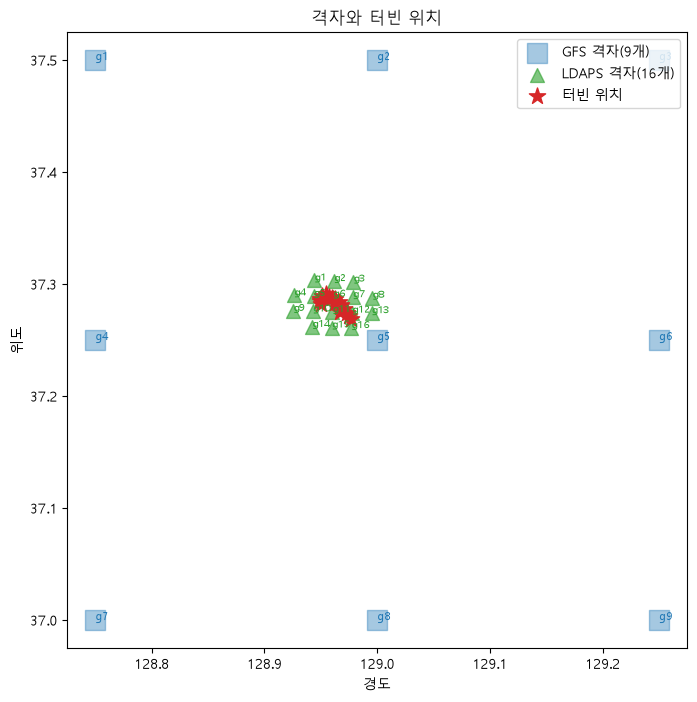

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(gfs_grid_meta["longitude"], gfs_grid_meta["latitude"], marker="s", s=200, c="tab:blue", alpha=0.4, label="GFS 격자(9개)")
ax.scatter(ldaps_grid_meta["longitude"], ldaps_grid_meta["latitude"], marker="^", s=100, c="tab:green", alpha=0.6, label="LDAPS 격자(16개)")
ax.scatter(turbine_coords["lon"], turbine_coords["lat"], marker="*", s=150, c="tab:red", label="터빈 위치")

for _, row in gfs_grid_meta.iterrows():
    ax.annotate(f"g{int(row['grid_id'])}", (row["longitude"], row["latitude"]), fontsize=8, color="tab:blue")
for _, row in ldaps_grid_meta.iterrows():
    ax.annotate(f"g{int(row['grid_id'])}", (row["longitude"], row["latitude"]), fontsize=7, color="tab:green")

ax.set_xlabel("경도")
ax.set_ylabel("위도")
ax.set_title("격자와 터빈 위치")
ax.legend()
plt.show()

**확인할 것**: 터빈(빨간 별)에 가장 가까운 GFS 격자 번호와 LDAPS 격자 번호가 몇 번인지 눈으로 확인해서 알려주세요 — `03_features.ipynb`에서 '최근접 격자' 피처를 만들 때 이 번호를 근거로 씁니다.

### 2-2. 결측치 컬럼별 분해

`reports/01_preprocessing.md`에 남겨둔 숙제입니다 — train_base 결측 17,741건, test_base 결측 752건이 정확히 어디서 나오는지 컬럼별로 쪼개봅니다.

In [17]:
train_na = train_base.isna().sum()
train_na = train_na[train_na > 0].sort_values(ascending=False)
print("train_base 결측 있는 컬럼 수:", len(train_na), "| 결측 총량:", train_na.sum())
train_na.head(20)

train_base 결측 있는 컬럼 수: 4 | 결측 총량: 17741


scada_kpx_group_3    8768
kpx_group_3          8766
kpx_group_1           104
kpx_group_2           103
dtype: int64

**확인할 것**: 상위권이 `kpx_group_3`, `scada_kpx_group_*` 처럼 원래 결측이 예상됐던 컬럼인지 확인하세요. 그 외 `gfs_*`/`ldaps_*` 예보 컬럼이 섞여 있다면 예보 누락일이 있다는 뜻이니, 몇 건인지·어떤 컬럼인지 알려주세요.

In [18]:
test_na = test_base.isna().sum()
test_na = test_na[test_na > 0].sort_values(ascending=False)
print("test_base 결측 있는 컬럼 수:", len(test_na), "| 결측 총량:", test_na.sum())
test_na.head(20)

test_base 결측 있는 컬럼 수: 304 | 결측 총량: 752


ldaps_g16_surface_0_lsm                   3
ldaps_g15_surface_0_lsm                   3
ldaps_g14_surface_0_lsm                   3
ldaps_g13_surface_0_lsm                   3
ldaps_g12_surface_0_lsm                   3
ldaps_g11_surface_0_lsm                   3
ldaps_g10_surface_0_lsm                   3
ldaps_g9_surface_0_lsm                    3
ldaps_g8_surface_0_lsm                    3
ldaps_g7_surface_0_lsm                    3
ldaps_g6_surface_0_lsm                    3
ldaps_g5_surface_0_lsm                    3
ldaps_g4_surface_0_lsm                    3
ldaps_g3_surface_0_lsm                    3
ldaps_g2_surface_0_lsm                    3
ldaps_g1_surface_0_lsm                    3
ldaps_g16_heightAboveGround_50_50MUmin    3
ldaps_g15_heightAboveGround_50_50MUmin    3
ldaps_g14_heightAboveGround_50_50MUmin    3
ldaps_g13_heightAboveGround_50_50MUmin    3
dtype: int64

In [19]:
# 결측이 있는 컬럼 중 하나를 골라, 실제로 어떤 시각에 결측인지 확인 (예보 누락일 후보 특정)
if len(test_na) > 0:
    sample_col = test_na.index[0]
    missing_times = test_base.loc[test_base[sample_col].isna(), "kst_dtm"]
    print(sample_col, "결측 시각 (", len(missing_times), "건):")
    print(missing_times)
else:
    print("test_base에 결측 없음")

ldaps_g16_surface_0_lsm 결측 시각 ( 3 건):
2344   2025-04-08 17:00:00
4049   2025-06-18 18:00:00
4757   2025-07-18 06:00:00
Name: kst_dtm, dtype: datetime64[us]


**확인할 것**: 결측 시각이 특정 날짜(예보 누락일)에 몰려 있는지, 아니면 여기저기 흩어져 있는지. 몰려 있다면 그 날짜를 기록해뒀다가 `03_features.ipynb`에서 보간(앞뒤 값으로 채우기 등) 방침을 정합니다.

### 2-3. 풍속 계산과 높이별·소스별 비교

바람은 u(동서 방향 성분), v(남북 방향 성분)로 나뉘어 있습니다. 파워커브와 비교하려면 방향과 상관없는 '풍속(속력)'이 필요한데, 피타고라스 정리와 같은 방식으로 **풍속 = sqrt(u² + v²)** 로 구합니다.

In [20]:
def wind_speed(df, u_col, v_col):
    return np.sqrt(df[u_col] ** 2 + df[v_col] ** 2)


# GFS: 9개 격자 평균 풍속을 높이별(10m/80m/100m/850hPa)로 계산
gfs_height_cols = {
    "10m": ("heightAboveGround_10_10u", "heightAboveGround_10_10v"),
    "80m": ("heightAboveGround_80_u", "heightAboveGround_80_v"),
    "100m": ("heightAboveGround_100_100u", "heightAboveGround_100_100v"),
    "850hPa": ("isobaricInhPa_850_u", "isobaricInhPa_850_v"),
}
for height, (u_suffix, v_suffix) in gfs_height_cols.items():
    speeds = [wind_speed(train_base, f"gfs_g{g}_{u_suffix}", f"gfs_g{g}_{v_suffix}") for g in range(1, 10)]
    train_base[f"gfs_ws_{height}_mean"] = pd.concat(speeds, axis=1).mean(axis=1)

# LDAPS: 16개 격자 평균 풍속 (10m만 u/v로 깔끔하게 존재)
ldaps_speeds = [wind_speed(train_base, f"ldaps_g{g}_heightAboveGround_10_10u", f"ldaps_g{g}_heightAboveGround_10_10v") for g in range(1, 17)]
train_base["ldaps_ws_10m_mean"] = pd.concat(ldaps_speeds, axis=1).mean(axis=1)

WS_COLS = ["gfs_ws_10m_mean", "gfs_ws_80m_mean", "gfs_ws_100m_mean", "gfs_ws_850hPa_mean", "ldaps_ws_10m_mean"]
train_base[WS_COLS].describe()

,gfs_ws_10m_mean,gfs_ws_80m_mean,gfs_ws_100m_mean,gfs_ws_850hPa_mean,ldaps_ws_10m_mean
count,26304.000000,26304.000000,26304.000000,26304.000000,26304.000000
mean,2.607444,3.684370,3.833557,8.037832,4.836247
std,1.364537,2.380676,2.534866,5.782873,2.479576
min,0.314381,0.326878,0.302544,0.368424,0.371642
25%,1.722248,2.103818,2.143360,3.400416,2.965037
50%,2.304835,3.067921,3.159977,6.321069,4.321871
75%,3.041773,4.434781,4.649444,11.625509,6.278099
max,13.128982,19.936785,21.017444,35.855114,16.874288


**확인할 것**: 평균 풍속이 10m < 80m < 100m 순으로 커지는지 — 이걸 **윈드시어**(높이가 올라갈수록 지표 마찰의 영향이 줄어 바람이 빨라지는 현상, 멱법칙으로 근사됨)라고 부르고, 실제로 이렇게 나와야 물리적으로 타당합니다. 850hPa(약 1,500m 상공)은 지상보다 훨씬 클 수 있습니다.

In [21]:
for group_col in GROUP_COLS:
    print(f"--- {group_col} ---")
    for col in WS_COLS:
        corr = train_base[col].corr(train_base[group_col])
        print(" ", col, "- 상관:", round(corr, 4))
    print()

--- kpx_group_1 ---
  gfs_ws_10m_mean - 상관: 0.5395
  gfs_ws_80m_mean - 상관: 0.5686
  gfs_ws_100m_mean - 상관: 0.5736
  gfs_ws_850hPa_mean - 상관: 0.7389
  ldaps_ws_10m_mean - 상관: 0.7298

--- kpx_group_2 ---
  gfs_ws_10m_mean - 상관: 0.5488
  gfs_ws_80m_mean - 상관: 0.5809
  gfs_ws_100m_mean - 상관: 0.5866
  gfs_ws_850hPa_mean - 상관: 0.7689
  ldaps_ws_10m_mean - 상관: 0.7395

--- kpx_group_3 ---
  gfs_ws_10m_mean - 상관: 0.5448
  gfs_ws_80m_mean - 상관: 0.5778
  gfs_ws_100m_mean - 상관: 0.5832
  gfs_ws_850hPa_mean - 상관: 0.7416
  ldaps_ws_10m_mean - 상관: 0.7338



**확인할 것**: 어느 높이의 풍속이 발전량과 가장 상관이 높은지 순위를 매겨서 알려주세요 — `03_features.ipynb`에서 어떤 높이를 주력 피처로 쓸지 정하는 근거가 됩니다.

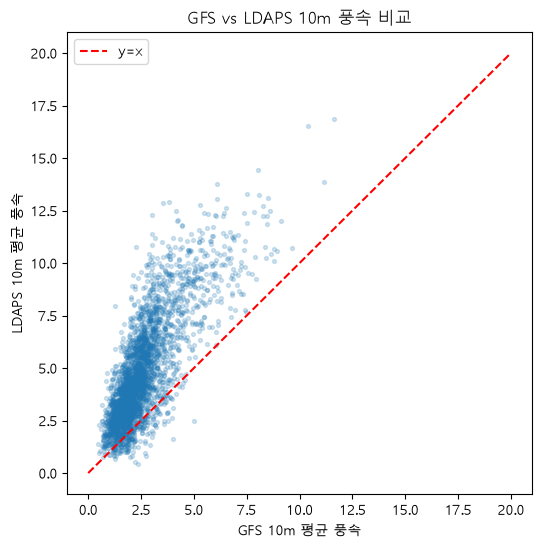

GFS-LDAPS 10m 풍속 상관: 0.7825


In [22]:
fig, ax = plt.subplots(figsize=(6, 6))
sample = train_base.sample(3000, random_state=SEED)
ax.scatter(sample["gfs_ws_10m_mean"], sample["ldaps_ws_10m_mean"], alpha=0.2, s=8)
ax.plot([0, 20], [0, 20], color="red", linestyle="--", label="y=x")
ax.set_xlabel("GFS 10m 평균 풍속")
ax.set_ylabel("LDAPS 10m 평균 풍속")
ax.set_title("GFS vs LDAPS 10m 풍속 비교")
ax.legend()
plt.show()

print("GFS-LDAPS 10m 풍속 상관:", round(train_base["gfs_ws_10m_mean"].corr(train_base["ldaps_ws_10m_mean"]), 4))

**확인할 것**: 점들이 빨간 y=x 선 근처에 모여 있는지(두 예보가 비슷하게 맞다는 뜻), 아니면 한쪽이 체계적으로 높거나 낮은지(편향). 차이가 크면 '두 소스가 서로 다르게 말한다'는 것 자체가 불확실성 정보이므로, 나중에 두 예측값의 차이를 피처로 쓸 근거가 됩니다.

### 2-4. 물리적 범위 점검

단위가 잘못 섞여 있으면(예: 켈빈과 섭씨 혼용) 항상 물리적으로 말이 안 되는 범위가 나옵니다. 대표 컬럼 몇 개만 범위를 확인합니다.

In [23]:
print("GFS g1 2m 기온(예상: 켈빈, K) 범위:", train_base["gfs_g1_heightAboveGround_2_2t"].min(), "~", train_base["gfs_g1_heightAboveGround_2_2t"].max())
print("LDAPS g1 2m 기온(예상: 켈빈, K) 범위:", train_base["ldaps_g1_heightAboveGround_2_t"].min(), "~", train_base["ldaps_g1_heightAboveGround_2_t"].max())
print("GFS g1 지표기압(예상: Pa) 범위:", train_base["gfs_g1_surface_0_sp"].min(), "~", train_base["gfs_g1_surface_0_sp"].max())

GFS g1 2m 기온(예상: 켈빈, K) 범위: 251.20033 ~ 305.82446
LDAPS g1 2m 기온(예상: 켈빈, K) 범위: 249.74907 ~ 302.03574
GFS g1 지표기압(예상: Pa) 범위: 90688.234 ~ 94558.96


**확인할 것**: 기온이 대략 230~320(켈빈, 섭씨 -43~47도에 해당 — 태백 지역 극한 기온을 넉넉히 포함하는 범위) 사이인지, 기압이 대략 85,000~103,000(Pa) 사이인지. 크게 벗어나면 단위 문제를 의심해야 합니다.

## 요약 및 다음 단계

1절(타깃)·2절(기상 예보 GFS/LDAPS) 실행 결과는 `reports/02_eda.md`에 Why/How/Result/So-what로 정리했습니다.

**이번 배치에서 확인된 핵심 포인트**
- 분포는 예상한 쌍봉이 아니라 L자형(0 근처 집중 후 완만히 감소)
- `kpx_group_1/2`에 2022-10-24~27 나흘 연속 결측 발견 (예상 밖 결측)
- test_base 결측 752건은 2025-04-08 17시/06-18 18시/07-18 06시 3개 시점에 완전히 집중 (예보 발표 누락 패턴)
- 발전량과 가장 상관 높은 예보 변수는 GFS 850hPa > LDAPS 10m > GFS 100m/80m > GFS 10m 순 (3개 그룹 공통) — 허브고도(117m)에 가까운 GFS 100m보다 자유대기(850hPa)가 더 높게 나온 것은 가설 단계, SCADA 대조 후 확정
- GFS 격자는 전 그룹이 g5 하나에 들어가고, LDAPS는 그룹별로 최근접 격자가 다름(계산 결과는 리포트 참고)
- 2025년 boxplot·월별 그래프 끝단은 실제 drift가 아니라 `2025-01-01 00:00` 단일 행 아티팩트이니 해석에서 제외

다음 배치는 3절(타깃×기상 관계 — 파워커브, 풍향별 발전량, 계절×풍속 상호작용), 4절(SCADA 심화 — 실측풍속 대조로 낮시간대 저발전이 curtailment 때문인지 실제 풍속 저하 때문인지 판별), 5절(시간 무결성 — 중복 타임스탬프, 시간 간격, train/test 경계)로 이어갑니다.